# Separation of Variables, Bessel Edition

The previous potential notebook separated variables in **Cartesian** (→ sines, Fourier) and
**spherical** (→ Legendre) geometry. The third member of the family is **cylindrical**: the radial
factor obeys *Bessel's equation*, so the modes are $J_m, Y_m$. And the spherical *Helmholtz*
equation (Laplace plus a $k^2$ term) gives the **spherical Bessel** functions $j_l, y_l$.

| geometry | equation | radial modes |
|---|---|---|
| Cartesian | Laplace | exponentials / sines |
| spherical | Laplace | $r^l,\ r^{-(l+1)}$ (Legendre in angle) |
| **cylindrical** | **Laplace/Helmholtz** | $J_m(ks),\ Y_m(ks)$ |
| **spherical** | **Helmholtz** | $j_l(kr),\ y_l(kr)$ |

The payoff for *this* repo is at the end: a **step-index optical fibre** guides light as $J_m$ in
the core and $K_m$ in the cladding — Bessel functions are literally the fibre modes the whole
dispersion pipeline propagates. Engine: `griffiths.bessel` (mpmath numerics, no scipy).

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import mpmath as mp
import matplotlib.pyplot as plt
from IPython.display import display, Math

import griffiths as gr
from griffiths import bessel as bz

sp.init_printing(use_latex="mathjax")
print("griffiths.bessel loaded (mpmath", mp.__version__ + ")")

griffiths.bessel loaded (mpmath 1.3.0)


## §1 Where Bessel's equation comes from

Separating $\nabla^2V=0$ in cylindrical coordinates $V=R(s)\Phi(\phi)Z(z)$ gives $\Phi=e^{im\phi}$,
$Z=e^{\pm kz}$, and a radial equation

$$s^2R''+sR'+(k^2s^2-m^2)R=0,$$

which is **Bessel's equation** (with $x=ks$). Its regular solution is $J_m$; the singular one is
$Y_m$ (dropped wherever the axis $s=0$ is included). SymPy confirms $J_m$ solves it exactly.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

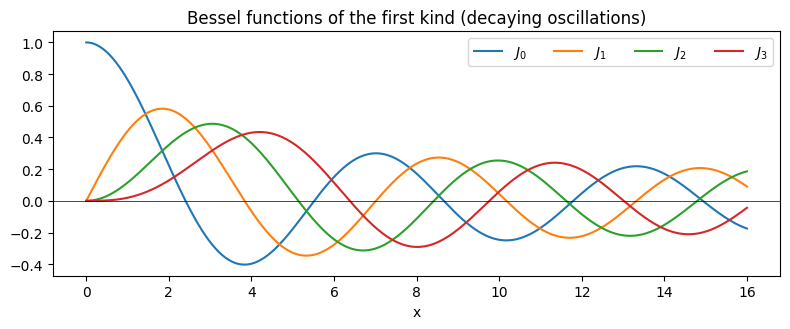

In [3]:
for m in (0, 1, 2):
    res = bz.bessel_ode_residual(m)
    display(Math(rf"s^2 J_{m}'' + s J_{m}' + (s^2-{m}^2)J_{m} = " + sp.latex(res)))

# plot J_0..J_3
s = np.linspace(0, 16, 400)
plt.figure(figsize=(8, 3.4))
for m in range(4):
    Jm = np.vectorize(lambda x, m=m: float(mp.besselj(m, x)))(s)
    plt.plot(s, Jm, label=f"$J_{m}$")
plt.axhline(0, color="k", lw=0.5); plt.legend(ncol=4)
plt.xlabel("x"); plt.title("Bessel functions of the first kind (decaying oscillations)")
plt.tight_layout(); plt.show()

## §2 Zeros and orthogonality — the Fourier-Bessel series

The zeros $\alpha_{m,n}$ of $J_m$ play the role $n\pi$ plays for sines: $\{J_m(\alpha_{m,n}s/a)\}$ is
a complete orthogonal basis on the disk $[0,a]$ (weight $s$). Any $f(s)$ expands as
$f=\sum_n c_n J_m(\alpha_{m,n}s/a)$ with
$c_n=\frac{2}{a^2 J_{m+1}(\alpha_{m,n})^2}\int_0^a f\,J_m(\alpha_{m,n}s/a)\,s\,ds.$

zeros of J_0: [ 2.4048  5.5201  8.6537 11.7915 14.9309]
zeros of J_1: [ 3.8317  7.0156 10.1735 13.3237 16.4706]


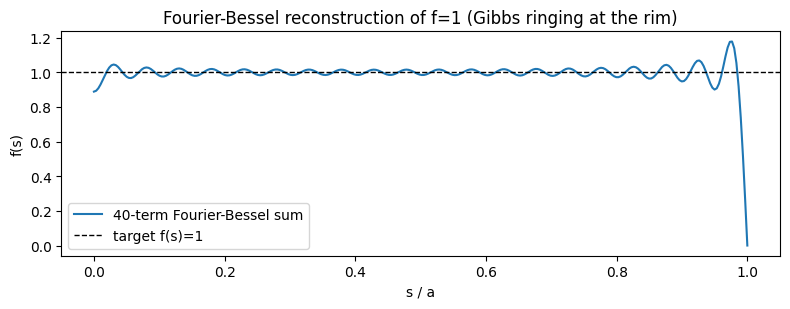

interior value at s=0.5: 0.9844 (target 1.0)


In [4]:
print("zeros of J_0:", np.round(bz.bessel_zeros(0, 5), 4))
print("zeros of J_1:", np.round(bz.bessel_zeros(1, 5), 4))

# expand f(s)=1 on the unit disk -> Fourier-Bessel series (the 'cylindrical square wave')
zeros, coeffs = bz.fourier_bessel_coeffs(lambda x: 1.0, 1.0, 40, order=0)
sg = np.linspace(0, 1, 300)
recon = np.array([bz.fourier_bessel_eval(zeros, coeffs, ss, 1.0) for ss in sg])
plt.figure(figsize=(8, 3.2))
plt.plot(sg, recon, label="40-term Fourier-Bessel sum")
plt.axhline(1, color="k", ls="--", lw=1, label="target f(s)=1")
plt.xlabel("s / a"); plt.ylabel("f(s)"); plt.legend()
plt.title("Fourier-Bessel reconstruction of f=1 (Gibbs ringing at the rim)")
plt.tight_layout(); plt.show()
print(f"interior value at s=0.5: {recon[150]:.4f} (target 1.0)")

## §3 A boundary-value problem: the capped cylinder

Grounded cylinder (radius $a$, height $L$): side and bottom held at $0$, the top cap at $V_0$.
Separation forces $J_0(\alpha_n s/a)$ radially (regular on the axis, zero at the wall) and
$\sinh(\alpha_n z/a)$ vertically (zero at the bottom). Matching $V_0$ on the cap is a Fourier-Bessel
expansion:

$$V(s,z)=\sum_n A_n\,J_0\!\Big(\frac{\alpha_n s}{a}\Big)\frac{\sinh(\alpha_n z/a)}{\sinh(\alpha_n L/a)}.$$

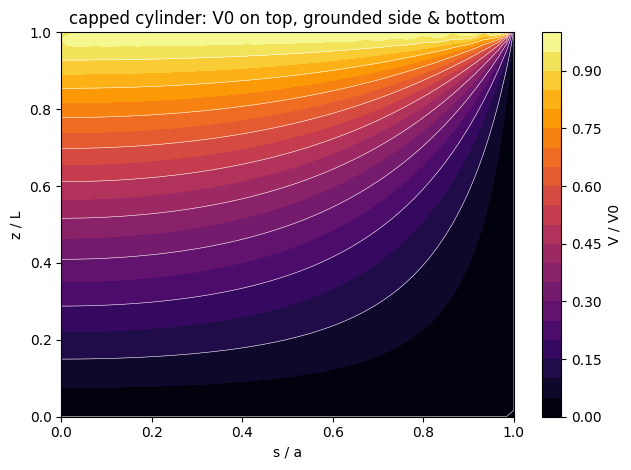

checks:  V(axis, bottom)= 0.0  V(axis, top)= 0.871  (Gibbs-limited ~1)


In [5]:
V = bz.cylinder_cap_potential(1.0, 1.0, 1.0, 30)
sg = np.linspace(0, 1, 60); zg = np.linspace(0, 1, 60)
SS, ZZ = np.meshgrid(sg, zg)
VV = np.vectorize(V)(SS, ZZ)

plt.figure(figsize=(6.5, 4.8))
cs = plt.contourf(SS, ZZ, np.clip(VV, 0, 1), levels=20, cmap="inferno")
plt.colorbar(cs, label="V / V0")
plt.contour(SS, ZZ, np.clip(VV, 0, 1), levels=10, colors="w", linewidths=0.4)
plt.xlabel("s / a"); plt.ylabel("z / L")
plt.title("capped cylinder: V0 on top, grounded side & bottom")
plt.tight_layout(); plt.show()
print("checks:  V(axis, bottom)=", round(V(0, 0), 3),
      " V(axis, top)=", round(V(0, 1), 3), " (Gibbs-limited ~1)")

## §4 Spherical Bessel and the infinite spherical well

Add a $k^2$ term (Helmholtz, $\nabla^2\psi+k^2\psi=0$) and the spherical radial factor becomes the
**spherical Bessel** $j_l(kr)=\sqrt{\tfrac{\pi}{2kr}}J_{l+1/2}(kr)$. Quantum payoff: a particle in an
infinite spherical well of radius $a$ must have $\psi\propto j_l(kr)$ with $j_l(ka)=0$, so the
allowed $k$ are the **zeros of $j_l$** and

$$E_{nl}=\frac{\hbar^2\beta_{nl}^2}{2m a^2},\qquad j_l(\beta_{nl})=0.$$

For $l=0$, $j_0(x)=\sin x/x$ so $\beta_{0n}=n\pi$ — the familiar 1-D box. Higher $l$ shifts the
levels up (the centrifugal barrier).

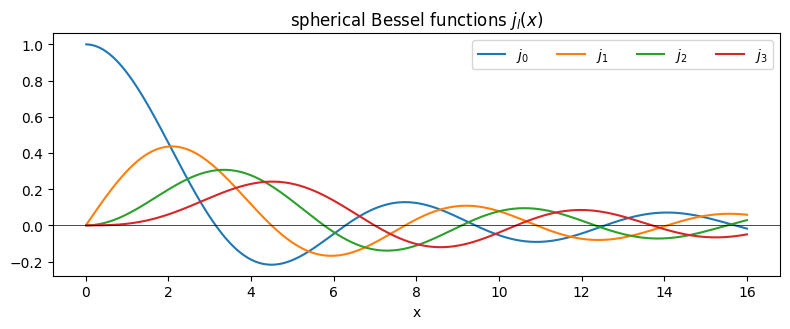

infinite spherical well levels (hbar=m=a=1):
  l=0: E = [4.935, 19.739, 44.413]
  l=1: E = [10.095, 29.84, 59.45]
  l=2: E = [16.609, 41.36, 75.927]
  l=0 are (n pi)^2/2: [4.935, 19.739, 44.413] -> the centrifugal barrier pushes l>0 up


In [6]:
x = np.linspace(0.01, 16, 400)
plt.figure(figsize=(8, 3.4))
for l in range(4):
    jl = np.vectorize(lambda v, l=l: float(sp.jn(l, v)))(x)
    plt.plot(x, jl, label=f"$j_{l}$")
plt.axhline(0, color="k", lw=0.5); plt.legend(ncol=4)
plt.xlabel("x"); plt.title("spherical Bessel functions $j_l(x)$")
plt.tight_layout(); plt.show()

print("infinite spherical well levels (hbar=m=a=1):")
for l in range(3):
    E = bz.spherical_well_energies(l, 3)
    print(f"  l={l}: E =", [round(e, 3) for e in E])
print("  l=0 are (n pi)^2/2:", [round((np.pi*n)**2/2, 3) for n in (1, 2, 3)],
      "-> the centrifugal barrier pushes l>0 up")

## §5 The repo's physics: step-index optical-fibre LP modes

A weakly-guiding step-index fibre is a cylindrical boundary-value problem. The guided field
oscillates as $J_m(ur/a)$ in the higher-index **core** and decays as $K_m(wr/a)$ in the **cladding**,
with $u^2+w^2=V^2$ ($V$ = the fibre's normalised frequency). Continuity at the core radius gives the
characteristic equation

$$u\frac{J_1(u)}{J_0(u)}=w\frac{K_1(w)}{K_0(w)}\quad(\text{LP}_{01}),$$

whose root sets the propagation constant. This $J_m$-in/$K_m$-out mode is exactly what the
dispersion pipeline in this repo propagates — Bessel functions are the alphabet of fibre optics.

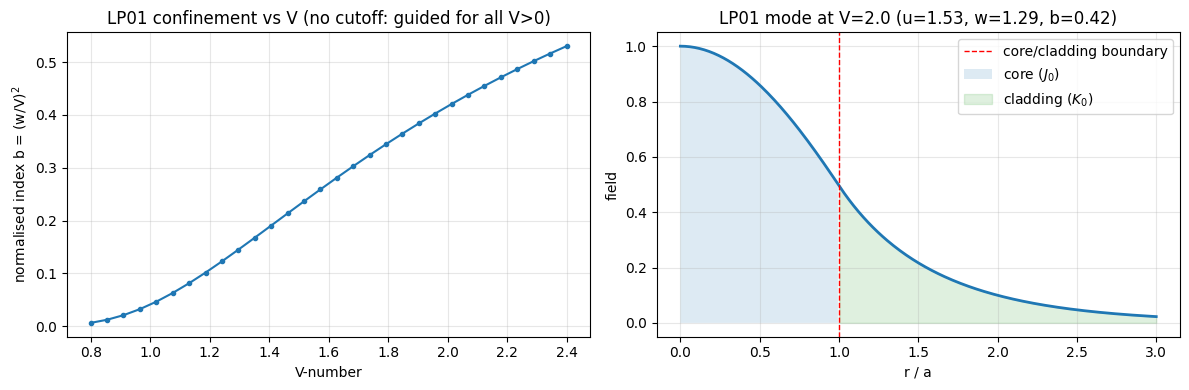

u^2 + w^2 = 4.0000 = V^2 = 4.0  -> energy split between core and cladding


: 

In [ ]:
# fundamental LP01 vs V-number: normalised index b = (w/V)^2 climbs toward 1
Vs = np.linspace(0.8, 2.4, 30)
bvals, us = [], []
for Vn in Vs:
    u, w, b = bz.fiber_LP01(Vn)
    bvals.append(b); us.append(u)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(Vs, bvals, "o-", ms=3)
axes[0].set_xlabel("V-number"); axes[0].set_ylabel("normalised index b = (w/V)$^2$")
axes[0].set_title("LP01 confinement vs V (no cutoff: guided for all V>0)")
axes[0].grid(alpha=0.3)

# the actual radial mode profile at V=2.0: J_0 core, K_0 cladding
u, w, b = bz.fiber_LP01(2.0)
a = 1.0
rg = np.linspace(0, 3, 300)
prof = np.array([bz.fiber_mode_profile(u, w, a, r) for r in rg])
axes[1].plot(rg, prof, lw=2)
axes[1].axvline(a, color="r", ls="--", lw=1, label="core/cladding boundary")
axes[1].fill_between(rg, prof, where=(rg < a), alpha=0.15, label="core ($J_0$)")
axes[1].fill_between(rg, prof, where=(rg >= a), alpha=0.15, color="C2", label="cladding ($K_0$)")
axes[1].set_xlabel("r / a"); axes[1].set_ylabel("field")
axes[1].set_title(f"LP01 mode at V=2.0 (u={u:.2f}, w={w:.2f}, b={b:.2f})")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"u^2 + w^2 = {u**2 + w**2:.4f} = V^2 = 4.0  -> energy split between core and cladding")

## §6 The throughline

- **One separation-of-variables method, three coordinate systems**: Cartesian→Fourier,
  spherical→Legendre (last notebook), cylindrical→Bessel (this one). The eigenfunctions differ; the
  recipe — separate, solve each ODE, match boundary conditions, sum — is identical, and it is the
  same recipe behind the FNO's spectral layers and the quantum-well solver.
- **Bessel zeros are the cylindrical $n\pi$**: the Fourier-Bessel series (§2) is the disk's Fourier
  series, and the infinite spherical well (§4) is the 3-D box.
- **Fibre modes (§5) close the loop**: the $J_m$/$K_m$ guided mode *is* the field this repo's
  dispersion and phase-retrieval pipeline operates on. Group-velocity dispersion — the diversity the
  TD-GS loop needs — is the frequency dependence of that mode's propagation constant. Bessel
  functions aren't a detour from the photonics; they're its foundation.

Engine added this session: `griffiths/bessel.py` (Bessel ODE check, zeros, Fourier-Bessel series,
capped-cylinder BVP, spherical Bessel + infinite spherical well, step-index fibre LP modes),
benchmarked in `scripts/smoke_bessel.py`. The `griffiths` package now covers all three separation-of-
variables geometries.